In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


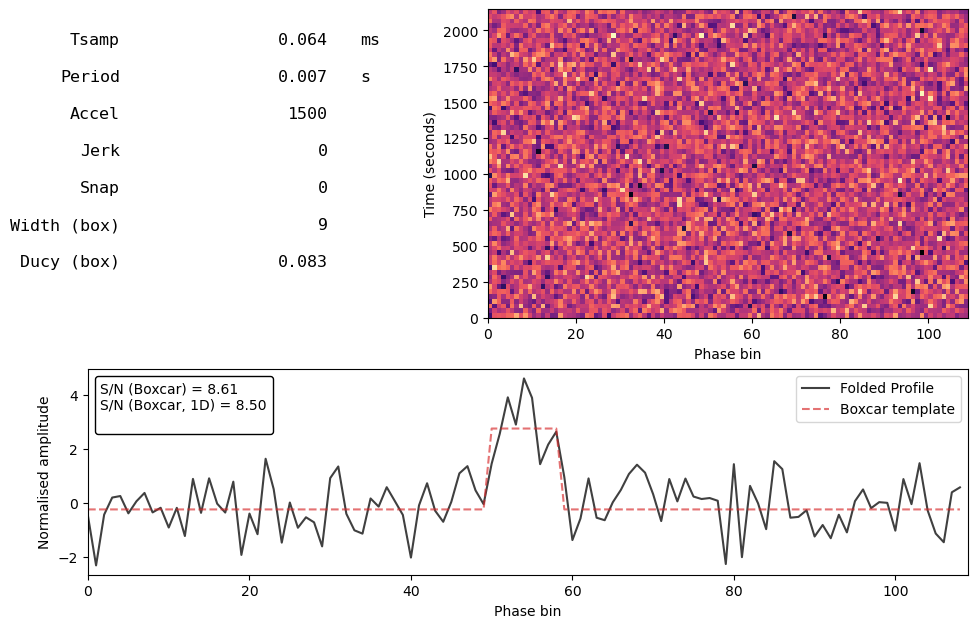

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 1500
nsamps = 2**25
mod_kwargs = {"acc": accel}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=8.5,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_taylor((140.0, 145.0), (-3000.0, 3000.0))
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=2,
    ducy_max=0.2,
    wtsp=1.5,
    use_fourier=True,
    use_conservative_tile=False,
    branch_max=32
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-3000.  3000.]
 [  140.   145.]]


2026-02-24 13:05:58 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [7.52164558e+06 1.19209290e-01]

2026-02-24 13:05:59 INFO     - pyloki.ffa - ffa level:  0, leaves: 5.36, fold dims: (8192, 1, 41, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 0.515 seconds

Output()

...

                    INFO     - pyloki.ffa - ffa level:  4, leaves:  9.39, fold dims: (512, 1, 671, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  5, leaves: 10.39, fold dims: (256, 1, 1342, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 12.98, fold dims: (128, 3, 2684, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.83633925e+03 1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 3.653 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="taylor", ref_seg=0)
branching_pattern

array([8.        , 3.        , 2.        , 3.        , 1.        ,
       1.        , 2.        , 3.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 2.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       2.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

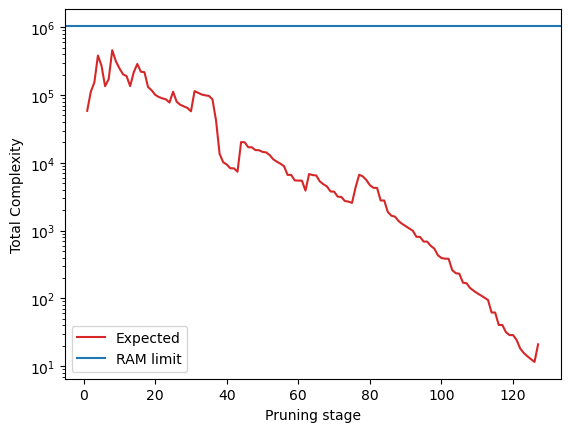

In [5]:
thresholds = np.array([2.1, 2.5, 2.6, 2.5, 2.7, 3. , 3.1, 2.9, 3.1, 3.1, 3.1, 2.9, 3.2,
       3.5, 3.6, 3.6, 3.2, 3.7, 3.6, 3.6, 3.5, 3.4, 3.3, 3.4, 3.9, 4. ,
       3.9, 3.8, 3.7, 3.8, 3.5, 3.6, 3.6, 3.5, 3.4, 3.6, 4.1, 4.5, 4.5,
       4.4, 4.4, 4. , 4.3, 4.3, 4. , 4.3, 4. , 4.2, 4. , 4.1, 4. , 4.1,
       4.2, 4.2, 4.2, 4.2, 4.4, 4. , 4.4, 4.2, 4.1, 4.5, 4.5, 4.4, 4.3,
       4.5, 4.5, 4.5, 4.6, 4.4, 4.6, 4.4, 4.6, 4.5, 4.5, 4.6, 4.4, 4.5,
       4.6, 4.7, 4.7, 4.4, 4.9, 4.5, 5. , 5. , 4.9, 5. , 5. , 5. , 5. ,
       5. , 5.1, 4.9, 5.1, 4.9, 5.1, 5.1, 5.2, 5.2, 5.1, 5. , 5.3, 5.3,
       5.2, 5.4, 5.3, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.6, 5.3, 5.7, 5.3,
       5.7, 5.7, 5.3, 5.7, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=8.5,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**20, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [6]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=32,
    max_sugg=2**20,
    outdir="pruning_results/accel_test/",
    file_prefix="test_accel",
    poly_basis="taylor",
    n_workers=4,
    use_moving_grid=True,
)

2026-02-24 13:06:03 INFO     - pyloki.prune - Starting Pruning for 32 runs, with 4 workers

Output()

2026-02-24 13:08:03 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/accel_test/test_accel_pruning_nstages_128_results.h5

In [7]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, run_id=None))

True params, a: 1500.000, f: 142.8571428571
Top candidates:
dparams: daccel: 0.2082993602, dfreq: 1.455191523e-05
Run: 094_24, S/N: 8.34, accel: 1500.02, freq: 142.857139
Run: 094_24, S/N: 8.31, accel: 1500.02, freq: 142.857154
Run: 094_24, S/N: 8.15, accel: 1499.81, freq: 142.857139
Run: 094_24, S/N: 8.08, accel: 1499.81, freq: 142.857124
Run: 045_12, S/N: 7.69, accel: 1500.13, freq: 142.857139
Run: 045_12, S/N: 7.59, accel: 1500.13, freq: 142.857125
Run: 094_24, S/N: 7.45, accel: 1499.60, freq: 142.857125
Run: 094_24, S/N: 7.43, accel: 1499.60, freq: 142.857111
Run: 094_24, S/N: 7.43, accel: 1499.81, freq: 142.857168
Run: 094_24, S/N: 7.40, accel: 1499.81, freq: 142.857154


In [8]:
print(pgram.get_best_in_each_run())

Best candidate in each run:
dparams: daccel: 0.2082993602, dfreq: 1.455191523e-05
Run: 000_01, S/N: 7.39, accel: 1500.06, freq: 142.857169
Run: 004_02, S/N: 6.95, accel: 2241.76, freq: 139.227174
Run: 008_03, S/N: 6.64, accel: 1982.66, freq: 141.146043
Run: 012_04, S/N: 6.41, accel: -1246.03, freq: 141.965406
Run: 016_05, S/N: 6.55, accel: 1555.84, freq: 142.259229
Run: 020_06, S/N: 6.51, accel: 1310.94, freq: 140.357181
Run: 024_07, S/N: 6.17, accel: -849.03, freq: 140.504365
Run: 028_08, S/N: 6.57, accel: 312.86, freq: 144.185911
Run: 032_09, S/N: 6.39, accel: -1925.13, freq: 142.560390
Run: 036_10, S/N: 6.67, accel: 192.86, freq: 142.852935
Run: 040_11, S/N: 6.48, accel: -365.39, freq: 143.727034
Run: 045_12, S/N: 7.69, accel: 1500.13, freq: 142.857139
Run: 049_13, S/N: 6.38, accel: -888.60, freq: 144.850544
Run: 053_14, S/N: 6.36, accel: -473.33, freq: 140.519506
Run: 057_15, S/N: 6.51, accel: 225.15, freq: 141.204686
Run: 061_16, S/N: 6.43, accel: 613.95, freq: 140.425107
Run: 065

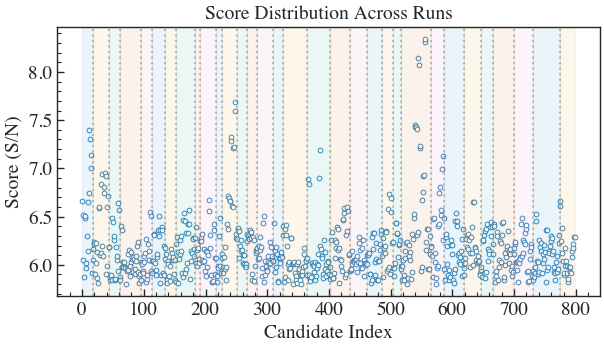

In [9]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

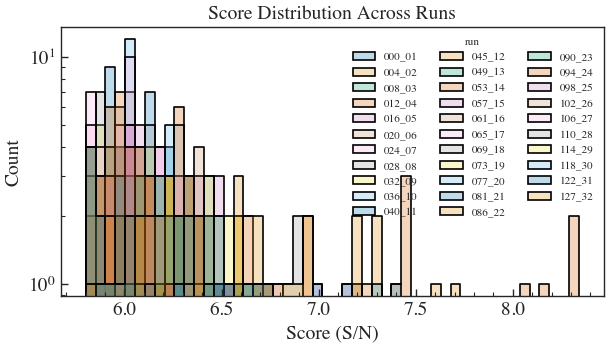

In [10]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

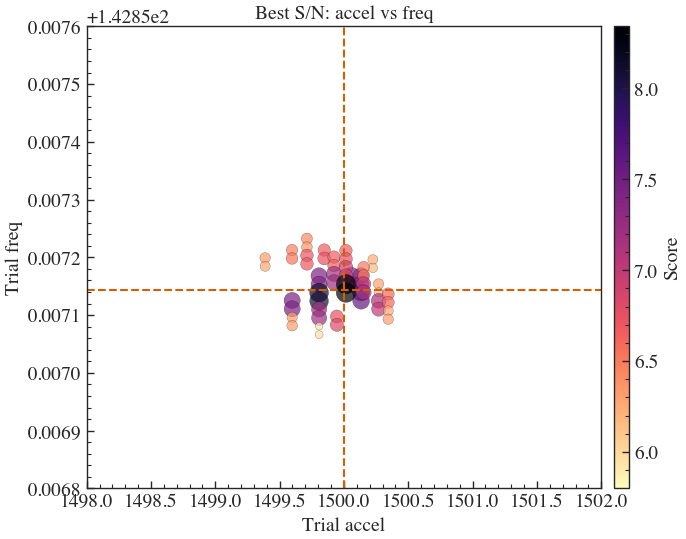

In [11]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, x_lim=(1498, 1502), y_lim=(142.8568, 142.8576), run_id=None)
plt.show()

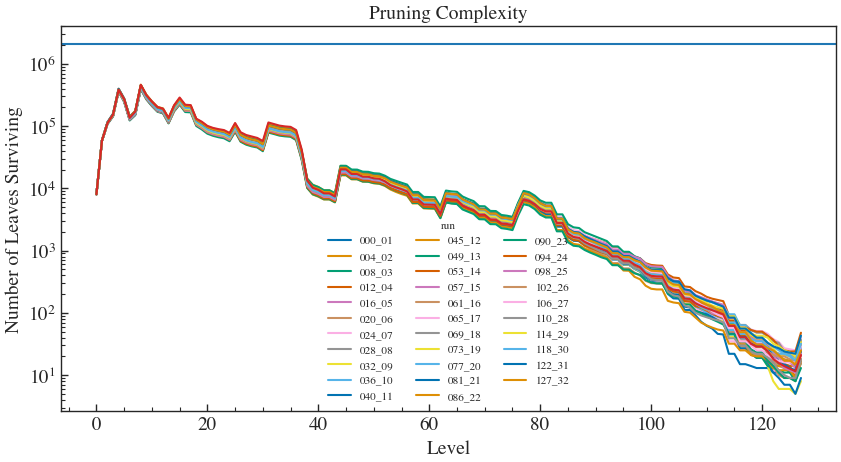

In [12]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**21, label="RAM limit", c="tab:blue")
plt.show()